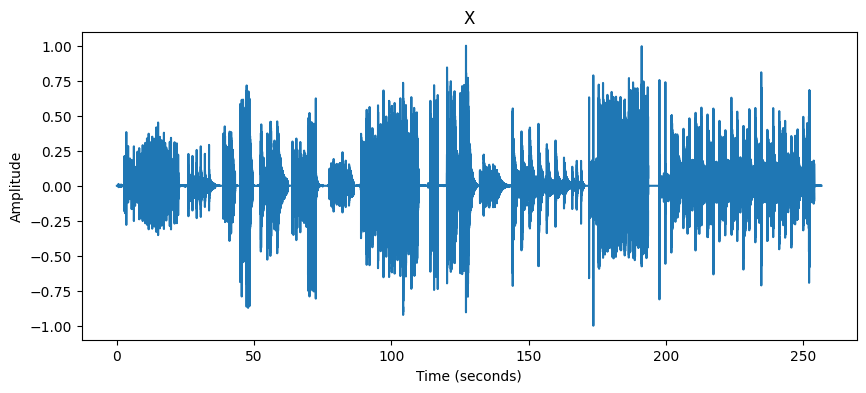

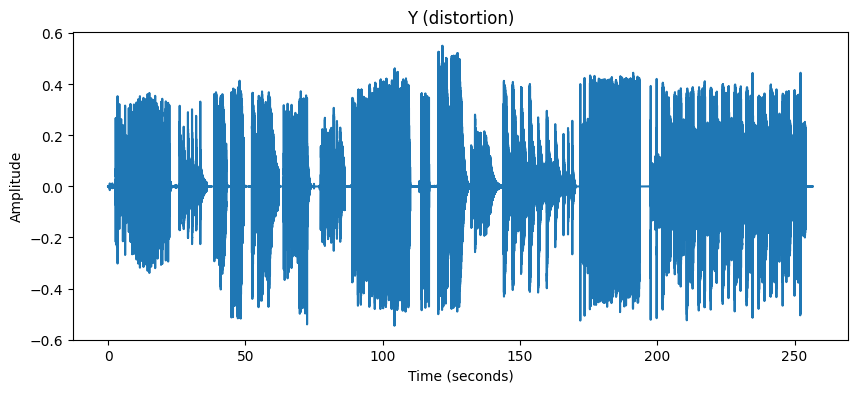

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def load_wav(path, sr=22050):
    audio, sample_rate = librosa.load(path, sr=sr)  # mono by default
    return audio, sample_rate

def plot_waveform(audio, title, sr):
    time = np.linspace(0, len(audio)/sr, num=len(audio))
    plt.figure(figsize=(10, 4))
    plt.plot(time, audio)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    #plt.xlim(10, 10.01)  # show only 0–1 seconds
    plt.ylabel("Amplitude")
    plt.show()

# Example
audio, sr = load_wav("Data/ML Guitar_ Initial_Data.wav")
plot_waveform(audio, "X", sr)
audio, sr = load_wav("Data/ML Guitar_ Target_Data.wav")
plot_waveform(audio, "Y (distortion)", sr)

In [2]:
import numpy as np
import torch
import torch.nn as nn
import librosa
import soundfile as sf
import time
import copy


# =====================================================================
# Config
# =====================================================================
class Config:
    sr          = 22050
    seq_len     = 256      # was 1024  -- 4x faster backprop
    batch_size  = 32       # was 64
    hidden      = 24       # was 32    -- minor, keeps it light
    layers      = 1
    lr          = 8e-3     # bump LR since fewer steps
    epochs      = 10       # was 20
    steps       = 100      # was 400   -- biggest single speedup
    block       = 512
    patience    = 3


cfg = Config()


# =====================================================================
# Data loading
# =====================================================================
def load_wav(path, sr):
    audio, _ = librosa.load(path, sr=sr)
    return audio.astype(np.float32)


def prepare_data():
    print("Loading audio...")
    x = load_wav("Data/ML Guitar_ Initial_Data.wav", cfg.sr)
    y = load_wav("Data/ML Guitar_ Target_Data.wav",  cfg.sr)

    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    print(f"  {n:,} samples  ({n/cfg.sr:.1f}s @ {cfg.sr} Hz)")

    split = int(0.8 * n)
    x_tr, x_te = x[:split], x[split:]
    y_tr, y_te = y[:split], y[split:]

    # peak-normalize using TRAIN peaks only
    peak_x = np.max(np.abs(x_tr)) + 1e-8
    peak_y = np.max(np.abs(y_tr)) + 1e-8
    x_tr, x_te = x_tr / peak_x, x_te / peak_x
    y_tr, y_te = y_tr / peak_y, y_te / peak_y

    return (x_tr, y_tr, x_te, y_te), (peak_x, peak_y)


# =====================================================================
# Model:  stateful, causal, sample-to-sample GRU
# =====================================================================
class DistortionGRU(nn.Module):
    """
    Input  shape: (batch, time, 1)
    Output shape: (batch, time, 1)
    Maps the whole sequence at once during training,
    and supports persistent state for real-time inference.
    """
    def __init__(self, hidden=cfg.hidden, layers=cfg.layers):
        super().__init__()
        self.gru = nn.GRU(1, hidden, layers, batch_first=True)
        self.fc  = nn.Linear(hidden, 1)

    def forward(self, x, state=None):
        out, state = self.gru(x, state)
        out = self.fc(out)
        return out, state


# =====================================================================
# Loss: Error-to-Signal Ratio with a pre-emphasis filter
#       (pre-emphasis greatly improves perceived quality on distortion)
# =====================================================================
def pre_emphasis(x, coeff=0.85):
    # x: (batch, time, 1)
    return x[:, 1:, :] - coeff * x[:, :-1, :]


def esr_loss(pred, target, eps=1e-8):
    pe_pred   = pre_emphasis(pred)
    pe_target = pre_emphasis(target)
    num = torch.sum((pe_pred - pe_target) ** 2)
    den = torch.sum(pe_target ** 2) + eps
    return num / den


# =====================================================================
# Batch sampler: random contiguous sequences
# =====================================================================
def sample_batch(x, y, device):
    n = len(x)
    starts = torch.randint(0, n - cfg.seq_len, (cfg.batch_size,))
    offs   = torch.arange(cfg.seq_len)
    idx    = starts.unsqueeze(1) + offs.unsqueeze(0)        # (B, seq_len)

    xb = x[idx].unsqueeze(-1).to(device)                   # (B, seq_len, 1)
    yb = y[idx].unsqueeze(-1).to(device)
    return xb, yb


# =====================================================================
# Training
# =====================================================================
def train(model, data, device):
    x_tr, y_tr, x_te, y_te = data
    x_tr = torch.from_numpy(x_tr)
    y_tr = torch.from_numpy(y_tr)
    x_te = torch.from_numpy(x_te).unsqueeze(0).unsqueeze(-1).to(device)
    y_te = torch.from_numpy(y_te).unsqueeze(0).unsqueeze(-1).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")
    print("Training...\n")

    # --- early stopping state ---
    best_loss   = float("inf")
    best_state  = copy.deepcopy(model.state_dict())
    patience    = cfg.patience      # epochs allowed with no improvement
    min_delta   = 1e-4              # what counts as "improvement"
    wait        = 0

    for epoch in range(cfg.epochs):
        model.train()
        t0 = time.time()
        running = 0.0

        for _ in range(cfg.steps):
            xb, yb = sample_batch(x_tr, y_tr, device)
            pred, _ = model(xb)
            warmup = cfg.seq_len // 8
            loss = esr_loss(pred[:, warmup:], yb[:, warmup:])

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item()

        train_loss = running / cfg.steps

        model.eval()
        with torch.no_grad():
            pred, _ = model(x_te)
            test_loss = esr_loss(pred, y_te).item()

        # --- check for improvement ---
        if test_loss < best_loss - min_delta:
            best_loss  = test_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            flag = "  <-- best"
        else:
            wait += 1
            flag = f"  (no improve {wait}/{patience})"

        print(f"Epoch {epoch+1:2d}/{cfg.epochs}  "
              f"train ESR={train_loss:.4f}  test ESR={test_loss:.4f}  "
              f"({time.time()-t0:.1f}s){flag}")

        if wait >= patience:
            print(f"\nEarly stopping. Best test ESR = {best_loss:.4f}")
            break

    # --- restore the best weights ---
    model.load_state_dict(best_state)
    print(f"Restored best model (test ESR = {best_loss:.4f})")

# =====================================================================
# Offline inference (full test set)
# =====================================================================
@torch.no_grad()
def render_test(model, data, peaks, device):
    x_tr, y_tr, x_te, y_te = data
    peak_x, peak_y = peaks

    model.eval()
    xt = torch.from_numpy(x_te).unsqueeze(0).unsqueeze(-1).to(device)
    pred, _ = model(xt)
    pred = pred.squeeze().cpu().numpy()

    sf.write("predicted_distortion.wav", pred  * peak_y, cfg.sr)
    sf.write("test_input_clean.wav",     x_te  * peak_x, cfg.sr)
    sf.write("test_target_true.wav",     y_te  * peak_y, cfg.sr)
    print("\nSaved predicted_distortion.wav / test_input_clean.wav / test_target_true.wav")

# =====================================================================
# Real-time streaming  (persistent hidden state, fully causal)
# =====================================================================
def stream_audio(model, peaks, input_device=None, output_device=None):
    import sounddevice as sd

    torch.set_num_threads(1)          # critical: no thread spawning in callback

    peak_x, peak_y = peaks
    in_scale  = 1.0 / peak_x
    out_scale = peak_y

    model = model.to("cpu").eval()

    # Pre-warm: run a few blocks so allocator / kernels are ready.
    with torch.no_grad():
        h = None
        for _ in range(5):
            _, h = model(torch.zeros(1, cfg.block, 1), h)

    state = {"h": None}

    @torch.no_grad()
    def callback(indata, outdata, frames, time_info, status):
        # NOTE: do NOT print inside the callback -- printing causes underflow!
        x = torch.from_numpy(indata[:, 0]).view(1, -1, 1) * in_scale
        y, state["h"] = model(x, state["h"])
        outdata[:, 0] = (y.view(-1) * out_scale).numpy()

    try:
        with sd.Stream(
            device=(input_device, output_device),
            channels=1,
            samplerate=cfg.sr,
            blocksize=cfg.block,
            latency="high",            # was "low" -- give the buffer slack
            dtype="float32",
            callback=callback,
        ):
            print(f"\nLive @ {cfg.sr} Hz, block {cfg.block} "
                  f"({cfg.block/cfg.sr*1000:.1f} ms). Press Enter to stop.")
            input()
    except sd.PortAudioError as e:
        print(f"\n[Audio error] {e}")
        print(sd.query_devices())


# =====================================================================
# Latency / throughput benchmark
# =====================================================================
@torch.no_grad()
def bench(model, n=100):
    model = model.to("cpu").eval()
    x = torch.zeros(1, cfg.block, 1)
    h = None
    y, h = model(x, h)  # warm
    t0 = time.perf_counter()
    for _ in range(n):
        y, h = model(x, h)
    dt = (time.perf_counter() - t0) / n
    budget = cfg.block / cfg.sr * 1000
    print(f"\n{dt*1000:.2f} ms/block   (budget {budget:.1f} ms)   "
          f"{'OK' if dt*1000 < budget else 'TOO SLOW'}")

In [3]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training device: {device}")

data, peaks = prepare_data()
model = DistortionGRU().to(device)


Training device: cpu
Loading audio...
  5,658,444 samples  (256.6s @ 22050 Hz)


In [4]:

train(model, data, device)
render_test(model, data, peaks, device)



Parameters: 1,969
Training...

Epoch  1/10  train ESR=0.2457  test ESR=0.1796  (13.8s)  <-- best
Epoch  2/10  train ESR=0.0340  test ESR=0.0380  (13.5s)  <-- best
Epoch  3/10  train ESR=0.0138  test ESR=0.0231  (13.4s)  <-- best
Epoch  4/10  train ESR=0.0114  test ESR=0.0165  (13.4s)  <-- best
Epoch  5/10  train ESR=0.0087  test ESR=0.0218  (13.6s)  (no improve 1/3)
Epoch  6/10  train ESR=0.0089  test ESR=0.0110  (14.0s)  <-- best
Epoch  7/10  train ESR=0.0089  test ESR=0.0178  (13.8s)  (no improve 1/3)
Epoch  8/10  train ESR=0.0088  test ESR=0.0114  (14.1s)  (no improve 2/3)
Epoch  9/10  train ESR=0.0078  test ESR=0.0131  (14.4s)  (no improve 3/3)

Early stopping. Best test ESR = 0.0110
Restored best model (test ESR = 0.0110)

Saved predicted_distortion.wav / test_input_clean.wav / test_target_true.wav


In [5]:

bench(model)
stream_audio(model, peaks)


4.91 ms/block   (budget 23.2 ms)   OK

Live @ 22050 Hz, block 512 (23.2 ms). Press Enter to stop.



================ Full test-set metrics ================
Test samples                  : 1,131,689 (51.3s)
ESR (whole test set)          : 0.0110
Worst 0.1% deviations (1,131 samples)
  mean |error| (normalized)   : 0.1694
  mean |error| (output scale) : 0.0934
Saved plot: segment_analysis.png


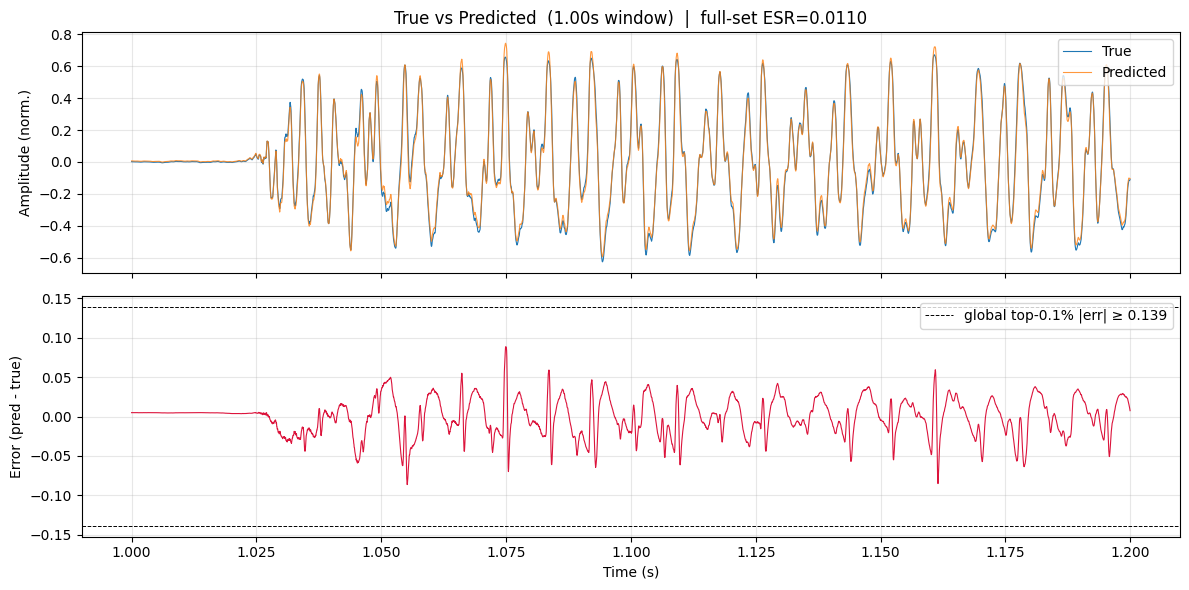

In [13]:
import matplotlib.pyplot as plt

@torch.no_grad()
def analyze_segment(model, data, peaks, device, plot_start_sec=1.0, plot_dur_sec=1.0):
    """
    Metrics  : computed over the ENTIRE test set.
    Plot     : only the window [plot_start_sec, plot_start_sec + plot_dur_sec].
    """
    x_tr, y_tr, x_te, y_te = data
    peak_x, peak_y = peaks

    model.eval()

    # --- run the model over the whole test signal (stateful, causal) ---
    xt = torch.from_numpy(x_te).unsqueeze(0).unsqueeze(-1).to(device)
    pred, _ = model(xt)
    pred = pred.squeeze().cpu().numpy()          # normalized scale
    true = y_te                                   # normalized scale

    # ================== METRICS: full test set ==================
    err = pred - true
    esr = np.sum(err ** 2) / (np.sum(true ** 2) + 1e-8)

    abs_err = np.abs(err)
    n_top = max(1, int(0.001 * len(abs_err)))     # top 0.1%
    worst = np.sort(abs_err)[-n_top:]
    worst_mean = worst.mean()

    print("\n================ Full test-set metrics ================")
    print(f"Test samples                  : {len(true):,} "
          f"({len(true)/cfg.sr:.1f}s)")
    print(f"ESR (whole test set)          : {esr:.4f}")
    print(f"Worst 0.1% deviations ({n_top:,} samples)")
    print(f"  mean |error| (normalized)   : {worst_mean:.4f}")
    print(f"  mean |error| (output scale) : {worst_mean * peak_y:.4f}")
    print("=======================================================")

    # ================== PLOT: chosen window only ==================
    a = int(plot_start_sec * cfg.sr)
    b = a + int(plot_dur_sec * cfg.sr)
    b = min(b, len(true))
    a = max(0, min(a, b - 1))

    true_w = true[a:b]
    pred_w = pred[a:b]
    err_w  = err[a:b]
    t = np.arange(len(true_w)) / cfg.sr + a / cfg.sr   # absolute time (s)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax1.plot(t, true_w, label="True",      linewidth=0.8)
    ax1.plot(t, pred_w, label="Predicted", linewidth=0.8, alpha=0.8)
    ax1.set_ylabel("Amplitude (norm.)")
    ax1.set_title(f"True vs Predicted  ({plot_start_sec:.2f}s window)  |  "
                  f"full-set ESR={esr:.4f}")
    ax1.legend(loc="upper right")
    ax1.grid(alpha=0.3)

    ax2.plot(t, err_w, color="crimson", linewidth=0.8)
    # threshold is taken from the WHOLE test set (so it's meaningful globally)
    thresh = worst.min()
    ax2.axhline( thresh, color="k", linestyle="--", linewidth=0.7,
                 label=f"global top-0.1% |err| ≥ {thresh:.3f}")
    ax2.axhline(-thresh, color="k", linestyle="--", linewidth=0.7)
    ax2.set_ylabel("Error (pred - true)")
    ax2.set_xlabel("Time (s)")
    ax2.legend(loc="upper right")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("segment_analysis.png", dpi=120)
    print("Saved plot: segment_analysis.png")
    plt.show()
analyze_segment(model, data, peaks, device, plot_start_sec=1.0, plot_dur_sec=0.2)
